In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mp291\codsoft\IMDb Movies India.csv", encoding="latin1")

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [6]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [7]:
df.dropna(inplace=True)
le=LabelEncoder()
df['Name']=le.fit_transform(df['Name'])
df['Genre']=le.fit_transform(df['Genre'])
df['Year']=le.fit_transform(df['Year'])
df['Duration']=le.fit_transform(df['Duration'])
df['Votes']=le.fit_transform(df['Votes'])

In [8]:
x=df[['Genre','Year','Duration','Votes']]
y=df['Rating']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=48)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [10]:
print("Mean square error of model:",mse)
print("R2 score:",r2)

Mean square error of model: 1.853892771183493
R2 score: 0.06850258895616845


In [11]:
sample_movie = [[5, 2024, 150, 250000]]
rating_predict=model.predict(sample_movie)
print("Prediction  of movie rating",rating_predict[0])

Prediction  of movie rating 6.434740319142356


C:\Users\mp291\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


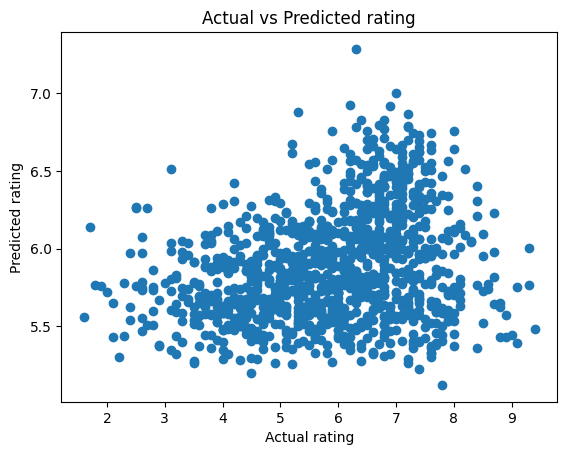

In [12]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual rating")
plt.ylabel("Predicted rating")
plt.title("Actual vs Predicted rating")
plt.show()